# Label Snapping Demo

Demonstrates the ridge-snapping misalignment correction on a small Safford tile.

**What it shows:** original hand-digitized polylines overlaid on a DEM hillshade, vs. the same lines after snapping each vertex to the local REM (Relative Elevation Model) crest along a perpendicular transect.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask as rio_mask
from scipy.ndimage import uniform_filter
from shapely.geometry import box
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# import snapping functions from the script
import importlib.util, types
spec = importlib.util.spec_from_file_location(
    "snap", Path("../scripts/snap_labels_to_dem.py"))
snap = importlib.util.module_from_spec(spec)
spec.loader.exec_module(snap)

LABELS_DIR  = Path("../data/raw/labels")
DEM_DIR     = Path("../data/raw/dem")
OUTPUT_DIR  = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Pick a demo tile

Select a ~2 km × 2 km window from Safford that contains several berms with visible misalignment.

In [2]:
# load all Safford berms and find a dense cluster to demo
gdf = gpd.read_file(LABELS_DIR / "safford_berms.shp")
print(f"Loaded {len(gdf)} Safford berms, CRS: {gdf.crs}")

# pick the 2km x 2km tile centred on the densest 1km² grid cell
xmin_all, ymin_all, xmax_all, ymax_all = gdf.total_bounds
cell = 1000
best_count, best_cx, best_cy = 0, 0, 0
for cx in np.arange(xmin_all, xmax_all, cell):
    for cy in np.arange(ymin_all, ymax_all, cell):
        tile_box = box(cx, cy, cx + cell, cy + cell)
        n = gdf[gdf.intersects(tile_box)].shape[0]
        if n > best_count:
            best_count, best_cx, best_cy = n, cx, cy

# expand to 2km x 2km around the dense centre
cx, cy = best_cx + cell / 2, best_cy + cell / 2
HALF = 1000  # metres
DEMO_BOUNDS = (cx - HALF, cy - HALF, cx + HALF, cy + HALF)
print(f"Demo tile centre: ({cx:.0f}, {cy:.0f})  →  {best_count} berms in core km²")
print(f"Demo bounds (EPSG:26912): {[round(v) for v in DEMO_BOUNDS]}")

Loaded 1219 Safford berms, CRS: EPSG:26912
Demo tile centre: (606816, 3650658)  →  56 berms in core km²
Demo bounds (EPSG:26912): [605816, 3649658, 607816, 3651658]


## 2. Load DEM and compute hillshade + REM

In [3]:
dem_arr, dem_tf, dem_res = snap.load_dem_for_bounds(DEM_DIR, DEMO_BOUNDS, buffer_m=300)
print(f"DEM shape: {dem_arr.shape}, resolution: {dem_res}m")
print(f"Elevation range: {np.nanmin(dem_arr):.1f}m – {np.nanmax(dem_arr):.1f}m")

# REM — removes regional hillslope trend; berms stand out as local highs
rem = snap.build_rem(dem_arr, window_m=50, res=dem_res)
print(f"REM range: {np.nanmin(rem):.2f}m – {np.nanmax(rem):.2f}m")

# hillshade for visualization
dem_display = np.where(np.isnan(dem_arr), 0, dem_arr)
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem_display, vert_exag=3, dx=dem_res, dy=dem_res)

DEM shape: (20012, 10012), resolution: 1.0m
Elevation range: 822.5m – 1586.1m
REM range: -19.52m – 34.22m


In [11]:
hillshade.shape

(20012, 10012)

## 3. Clip labels to demo tile

In [4]:
demo_box = box(*DEMO_BOUNDS)
gdf_tile = gdf[gdf.intersects(demo_box)].copy().reset_index(drop=True)
print(f"Berms in demo tile: {len(gdf_tile)}")

Berms in demo tile: 142


## 4. Run the snapping algorithm

In [5]:
params = {
    "vertex_spacing":      1.0,
    "transect_half_width": 12,
    "transect_samples":    25,
    "max_shift":           13,
    "prominence_thresh":   0.05,
    "smooth_window":       5,
}

snapped_geoms, mean_shifts, flag_fracs = [], [], []
for _, row in gdf_tile.iterrows():
    new_geom, mean_s, flag_f, failed = snap.process_feature(
        row.geometry, rem, dem_tf, params
    )
    snapped_geoms.append(new_geom if not failed else row.geometry)
    mean_shifts.append(mean_s)
    flag_fracs.append(flag_f)

gdf_snapped = gdf_tile.copy()
gdf_snapped["geometry"]   = snapped_geoms
gdf_snapped["snap_shift"] = np.round(mean_shifts, 2)
gdf_snapped["needs_qc"]   = np.array(flag_fracs) > 0.5

shifted = gdf_snapped[gdf_snapped["snap_shift"] > 0]
print(f"Features snapped    : {len(shifted)}/{len(gdf_tile)}")
print(f"Mean shift          : {gdf_snapped['snap_shift'].mean():.2f} m")
print(f"Max shift           : {gdf_snapped['snap_shift'].max():.2f} m")
print(f"Flagged for QC      : {gdf_snapped['needs_qc'].sum()}")

Features snapped    : 142/142
Mean shift          : 4.48 m
Max shift           : 9.15 m
Flagged for QC      : 0


## 5. Side-by-side comparison

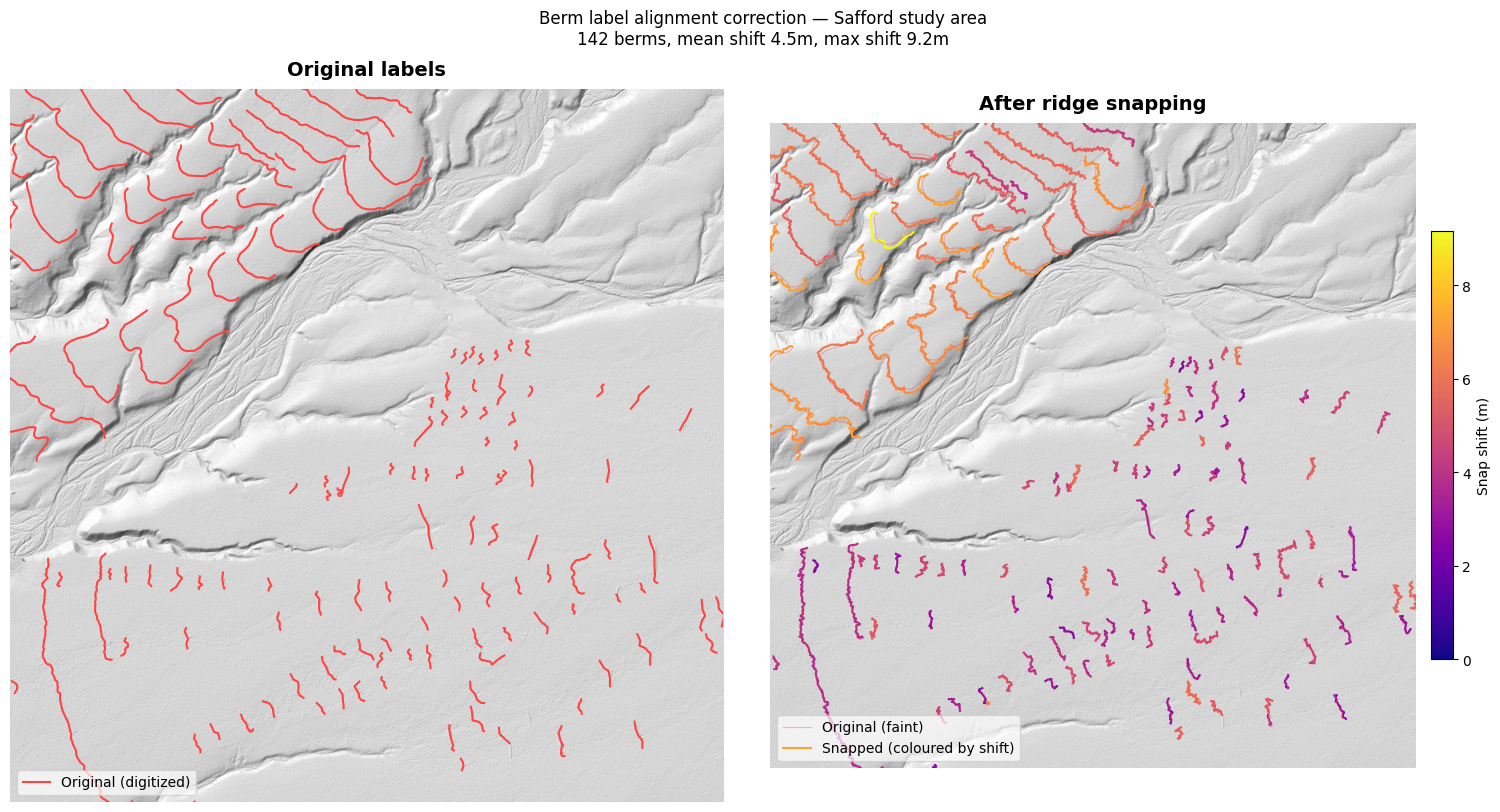

Saved: ../outputs/snap_labels_demo.png


In [6]:
def world_to_pixel(x, y, transform):
    """Convert world coordinates to pixel (col, row)."""
    col = (x - transform.c) / transform.a
    row = (y - transform.f) / transform.e
    return col, row

def plot_lines_on_ax(ax, gdf_lines, transform, color, lw, label, alpha=1.0):
    for geom in gdf_lines.geometry:
        if geom is None or geom.is_empty:
            continue
        lines = [geom] if geom.geom_type == "LineString" else list(geom.geoms)
        for line in lines:
            coords = np.array(line.coords)[:, :2]
            cols, rows = world_to_pixel(coords[:, 0], coords[:, 1], transform)
            ax.plot(cols, rows, color=color, linewidth=lw, alpha=alpha)
    # legend proxy
    ax.plot([], [], color=color, linewidth=lw, alpha=alpha, label=label)

# ---- figure ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)

# compute display extent clipped to demo tile
xmin, ymin, xmax, ymax = DEMO_BOUNDS
c0, r0 = world_to_pixel(xmin, ymax, dem_tf)  # top-left in pixel space
c1, r1 = world_to_pixel(xmax, ymin, dem_tf)  # bottom-right

for ax in axes:
    ax.imshow(hillshade, cmap="gray", vmin=0, vmax=1, interpolation="bilinear")
    ax.set_xlim(c0, c1)
    ax.set_ylim(r1, r0)
    ax.axis("off")

# LEFT — original
plot_lines_on_ax(axes[0], gdf_tile,    dem_tf, color="#FF4444", lw=1.5, label="Original (digitized)")
axes[0].set_title("Original labels", fontsize=14, fontweight="bold", pad=10)
axes[0].legend(loc="lower left", fontsize=10, framealpha=0.7)

# RIGHT — snapped, colour-coded by shift magnitude
norm_shift = plt.Normalize(vmin=0, vmax=gdf_snapped["snap_shift"].max() or 1)
cmap = plt.cm.plasma
for _, row in gdf_snapped.iterrows():
    geom = row.geometry
    if geom is None or geom.is_empty:
        continue
    lines = [geom] if geom.geom_type == "LineString" else list(geom.geoms)
    color = cmap(norm_shift(row["snap_shift"]))
    for line in lines:
        coords = np.array(line.coords)[:, :2]
        cols, rows = world_to_pixel(coords[:, 0], coords[:, 1], dem_tf)
        axes[1].plot(cols, rows, color=color, linewidth=1.5)

# also draw original faintly on right panel so offset is visible
plot_lines_on_ax(axes[1], gdf_tile, dem_tf,
                 color="#FF4444", lw=0.8, alpha=0.35, label="Original (faint)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_shift)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1], shrink=0.6, pad=0.02)
cbar.set_label("Snap shift (m)", fontsize=10)

axes[1].plot([], [], color=cmap(0.8), linewidth=1.5, label="Snapped (coloured by shift)")
axes[1].legend(loc="lower left", fontsize=10, framealpha=0.7)
axes[1].set_title("After ridge snapping", fontsize=14, fontweight="bold", pad=10)

fig.suptitle(
    f"Berm label alignment correction — Safford study area\n"
    f"{len(gdf_tile)} berms, mean shift {gdf_snapped['snap_shift'].mean():.1f}m, "
    f"max shift {gdf_snapped['snap_shift'].max():.1f}m",
    fontsize=12, y=1.01,
)
plt.tight_layout()
out_path = OUTPUT_DIR / "snap_labels_demo.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## 6. Shift distribution

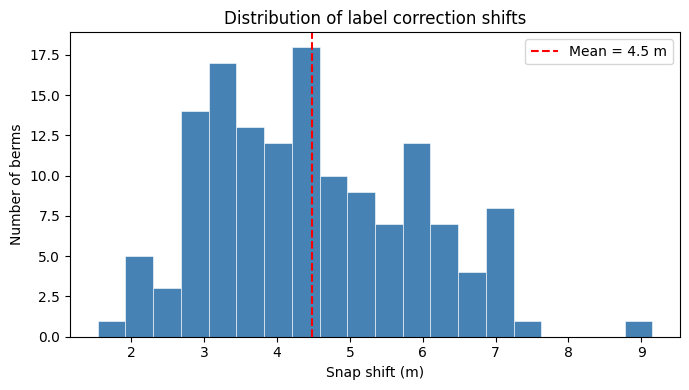


142 of 142 berms shifted
  mean: 4.48m
  median: 4.30m
  >5m shift: 47 berms
  >8m shift: 1 berms


In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
shifted_vals = gdf_snapped.loc[gdf_snapped["snap_shift"] > 0, "snap_shift"]
ax.hist(shifted_vals, bins=20, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(shifted_vals.mean(), color="red", linestyle="--",
           label=f"Mean = {shifted_vals.mean():.1f} m")
ax.set_xlabel("Snap shift (m)")
ax.set_ylabel("Number of berms")
ax.set_title("Distribution of label correction shifts")
ax.legend()
plt.tight_layout()
plt.show()
print(f"\n{len(shifted_vals)} of {len(gdf_tile)} berms shifted")
print(f"  mean: {shifted_vals.mean():.2f}m")
print(f"  median: {shifted_vals.median():.2f}m")
print(f"  >5m shift: {(shifted_vals > 5).sum()} berms")
print(f"  >8m shift: {(shifted_vals > 8).sum()} berms")

## 7. Close-up: single berm before vs. after

Selected berm index 32: length=54m, shift=4.89m


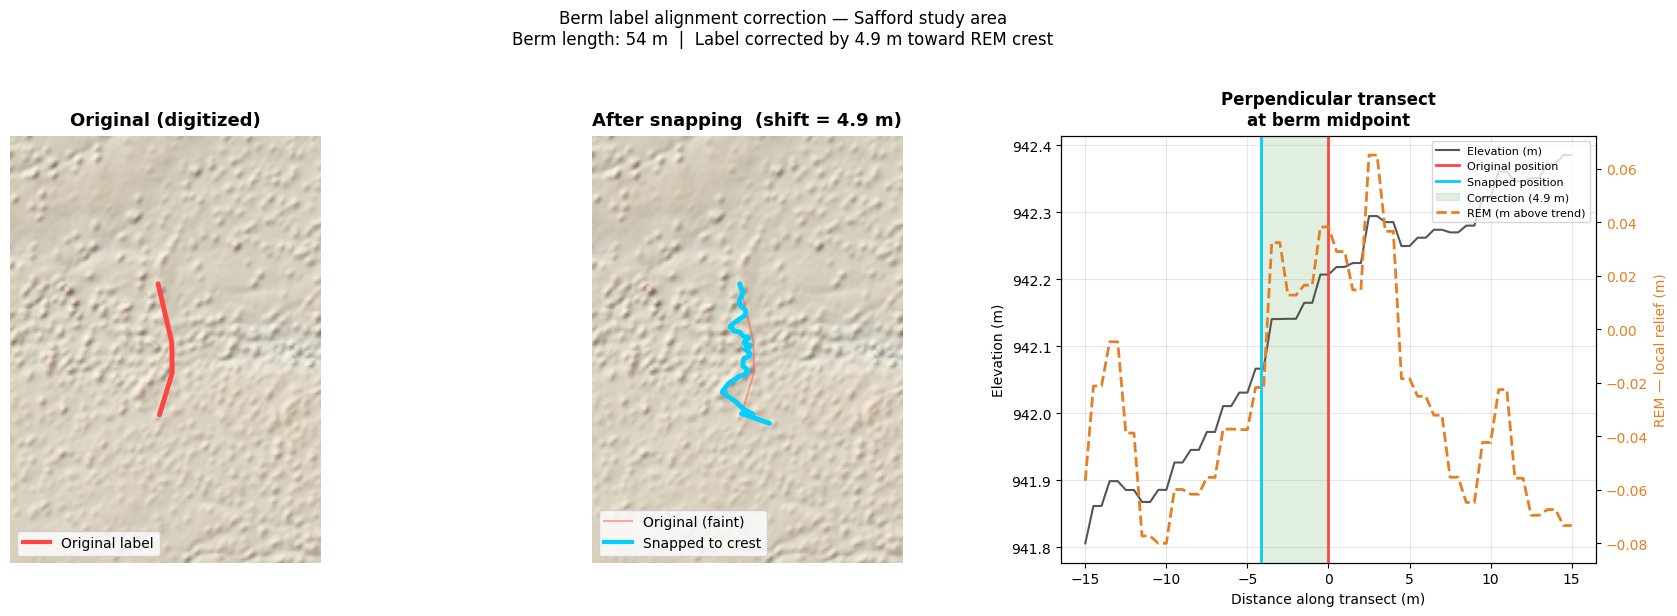

Saved: ../outputs/snap_labels_closeup.png


In [12]:
# ── pick a berm with a believable median shift (not the outlier max) ──────
candidates = gdf_snapped[
    (gdf_snapped["snap_shift"] > 0) &
    (~gdf_snapped["needs_qc"]) &
    (gdf_snapped.geometry.length > 80)
].copy()
p40 = candidates["snap_shift"].quantile(0.4)
p60 = candidates["snap_shift"].quantile(0.6)
median_band = candidates[candidates["snap_shift"].between(p40, p60)]
if len(median_band) == 0:
    median_band = candidates  # fallback
best_idx     = median_band["snap_shift"].sub(candidates["snap_shift"].median()).abs().idxmin()
orig_line    = gdf_tile.loc[best_idx].geometry
snapped_line = gdf_snapped.loc[best_idx].geometry
shift_val    = gdf_snapped.loc[best_idx]["snap_shift"]
print(f"Selected berm index {best_idx}: length={orig_line.length:.0f}m, shift={shift_val:.2f}m")

# ── close-up spatial extent ───────────────────────────────────────────────
pad = 60
bx0, by0, bx1, by1 = orig_line.bounds
close_bounds = (bx0 - pad, by0 - pad, bx1 + pad, by1 + pad)
cc0, cr0 = world_to_pixel(close_bounds[0], close_bounds[3], dem_tf)
cc1, cr1 = world_to_pixel(close_bounds[2], close_bounds[1], dem_tf)

# ── high-quality hillshade (vert_exag=8 makes 0.5m berms visible) ─────────
hillshade_hq = LightSource(azdeg=315, altdeg=35).hillshade(
    dem_display, vert_exag=8, dx=dem_res, dy=dem_res
)

# ── elevation cross-section at berm midpoint ──────────────────────────────
densified   = snap.densify(orig_line, 1.0)
mid_i       = len(densified) // 2
mid_pt      = densified[mid_i:mid_i+1]            # shape (1,2)
perp        = snap.perpendicular_dirs(densified)[mid_i]   # shape (2,)
offsets     = np.linspace(-15, 15, 61)
transect_xy = mid_pt + perp[np.newaxis, :] * offsets[:, np.newaxis]
elev_vals   = snap.sample_raster(dem_arr, dem_tf, transect_xy)
rem_vals    = snap.sample_raster(rem,     dem_tf, transect_xy)

# find where the snapped midpoint sits on the transect
snapped_densified = snap.densify(snapped_line, 1.0)
snapped_mid  = snapped_densified[len(snapped_densified) // 2]
snap_offset  = float(np.dot(snapped_mid - mid_pt[0], perp))  # signed offset (m)

# ── figure: 1x3 layout ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 6))
ax_orig = fig.add_subplot(1, 3, 1)
ax_snap = fig.add_subplot(1, 3, 2, sharex=ax_orig, sharey=ax_orig)
ax_prof = fig.add_subplot(1, 3, 3)

def draw_map(ax):
    ax.imshow(hillshade_hq, cmap="gray", vmin=0, vmax=1, interpolation="bilinear")
    ax.imshow(np.clip(rem, -0.3, 0.8), cmap="YlOrRd",
              vmin=-0.3, vmax=0.8, alpha=0.18, interpolation="bilinear")
    ax.set_xlim(cc0, cc1)
    ax.set_ylim(cr1, cr0)
    ax.axis("off")

def draw_line(ax, geom, color, lw, alpha=1.0):
    parts = [geom] if geom.geom_type == "LineString" else list(geom.geoms)
    for part in parts:
        coords = np.array(part.coords)[:, :2]
        c, r = world_to_pixel(coords[:, 0], coords[:, 1], dem_tf)
        ax.plot(c, r, color=color, linewidth=lw, alpha=alpha, solid_capstyle="round")

# LEFT: original
draw_map(ax_orig)
draw_line(ax_orig, orig_line, "#FF4444", 3.5)
ax_orig.plot([], [], color="#FF4444", lw=3, label="Original label")
ax_orig.legend(loc="lower left", fontsize=10, framealpha=0.8)
ax_orig.set_title("Original (digitized)", fontsize=13, fontweight="bold", pad=8)

# MIDDLE: snapped
draw_map(ax_snap)
draw_line(ax_snap, orig_line,    "#FF4444", 1.5, alpha=0.45)
draw_line(ax_snap, snapped_line, "#00CFFF", 3.5)
ax_snap.plot([], [], color="#FF4444", lw=1.5, alpha=0.45, label="Original (faint)")
ax_snap.plot([], [], color="#00CFFF", lw=3,              label="Snapped to crest")
ax_snap.legend(loc="lower left", fontsize=10, framealpha=0.8)
ax_snap.set_title(f"After snapping  (shift = {shift_val:.1f} m)",
                   fontsize=13, fontweight="bold", pad=8)

# RIGHT: perpendicular elevation transect
valid = ~np.isnan(elev_vals)
ax2 = ax_prof.twinx()
ax_prof.plot(offsets[valid], elev_vals[valid], color="#555555", lw=1.5,
             label="Elevation (m)", zorder=2)
ax2.plot(offsets[valid], rem_vals[valid], color="#E67E22", lw=2,
         linestyle="--", label="REM (m above trend)", zorder=3)
ax_prof.axvline(0,           color="#FF4444", lw=2, linestyle="-",
                label="Original position", zorder=4)
ax_prof.axvline(snap_offset, color="#00CFFF", lw=2, linestyle="-",
                label="Snapped position",  zorder=4)
ax_prof.axvspan(min(0, snap_offset), max(0, snap_offset),
                alpha=0.12, color="green",
                label=f"Correction ({shift_val:.1f} m)")
ax_prof.set_xlabel("Distance along transect (m)", fontsize=10)
ax_prof.set_ylabel("Elevation (m)", fontsize=10)
ax2.set_ylabel("REM — local relief (m)", fontsize=10, color="#E67E22")
ax2.tick_params(axis="y", labelcolor="#E67E22")
ax_prof.set_title("Perpendicular transect\nat berm midpoint",
                   fontsize=12, fontweight="bold", pad=8)
lines1, labels1 = ax_prof.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_prof.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")
ax_prof.grid(True, alpha=0.3)

fig.suptitle(
    f"Berm label alignment correction — Safford study area\n"
    f"Berm length: {orig_line.length:.0f} m  |  Label corrected by {shift_val:.1f} m toward REM crest",
    fontsize=12, y=1.02,
)
plt.tight_layout()
out_path2 = OUTPUT_DIR / "snap_labels_closeup.png"
plt.savefig(out_path2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path2}")